In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [3]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [4]:
df_DA_US['salary_year_avg'].sample(10)

346881    159133.00000
322577    120000.00000
22019      75000.00000
183599     90250.00000
564720     80000.00000
540141     73128.84375
10463     115000.00000
597429    100000.00000
660360    111175.00000
394317    175500.00000
Name: salary_year_avg, dtype: float64

<Axes: >

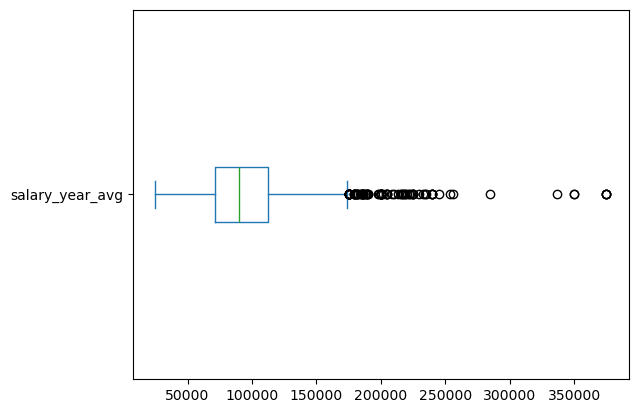

In [6]:
df_DA_US['salary_year_avg'].plot(kind='box', vert=False)

In [17]:
job_titles = ['Data Analyst','Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

In [18]:
df_US = df_US.dropna(subset=['salary_year_avg'])

In [19]:
job_list= [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
job_list[0]

109        89000.0
180        90250.0
410       133285.0
988        62623.0
1413       71300.0
            ...   
782637     70000.0
782798    111175.0
783588    125000.0
783866    115000.0
784882     87500.0
Name: salary_year_avg, Length: 4350, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x21f688c87d0>,
 'caps': [<matplotlib.lines.Line2D at 0x21f688c8a50>,
 'boxes': [<matplotlib.lines.Line2D at 0x21f688c8690>,
 'medians': [<matplotlib.lines.Line2D at 0x21f688c8cd0>,
 'fliers': [<matplotlib.lines.Line2D at 0x21f688c8e10>,
 'means': []}

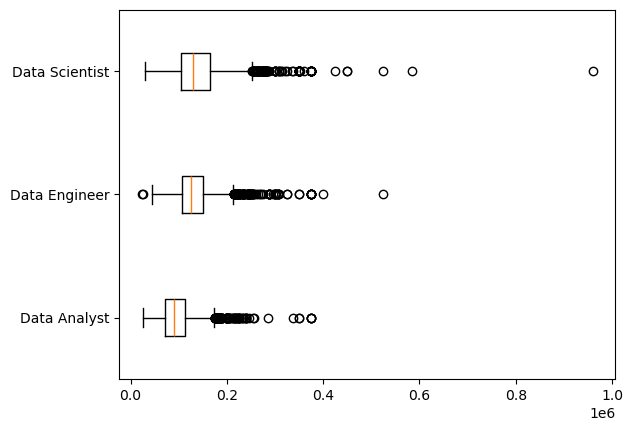

In [20]:
plt.boxplot(job_list, tick_labels=job_titles, vert=False)